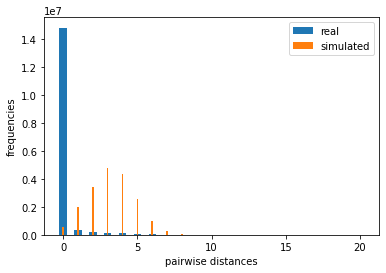

In [17]:

import numpy as np
from matplotlib import pyplot

real = [14819263, 309978, 201843, 157024, 110165, 68130, 35248, 17715, 11338, 6727, 4856, 2606, 1558, 771, 622, 200, 32, 23, 9, 42, 0]
simulated = [554804, 2013468, 3399605, 4772174, 4384087, 2529045, 983402, 283135, 65234, 12516, 2205, 272, 35, 18, 0, 0,0,0, 0, 0, 0]
bar1 = pyplot.bar(np.arange(len(real)), real, width=0.5)
bar2 = pyplot.bar(np.arange(len(simulated)), simulated, width=0.1)

pyplot.legend( (bar1[0], bar2[0]), ('real', 'simulated'))
pyplot.ylabel('frequencies')
pyplot.xlabel('pairwise distances')
pyplot.show()


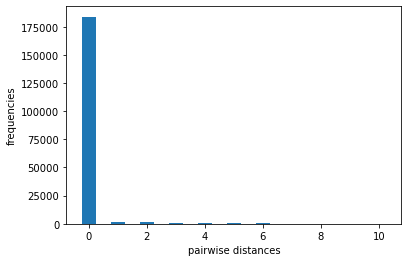

96.79052631578948

In [19]:
import numpy as np
from matplotlib import pyplot

test = [183902,   2014,   1281,   1003,    731,    482,    330,    187,     53,     17, 0]
bar1 = pyplot.bar(np.arange(len(test)), test, width=0.5)

#pyplot.legend( (bar1[0], bar2[0]), ('real', 'simulated'))
pyplot.ylabel('frequencies')
pyplot.xlabel('pairwise distances')
pyplot.show()

test[0]/sum(test)*100

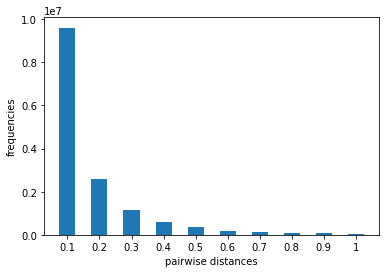

95.61821019360193

In [22]:
import numpy as np
from matplotlib import pyplot

test = [9604155, 2576887, 1138483,  593650,  339157,  199294,  123529,   88095,   62124, 46406]
bar1 = pyplot.bar(np.arange(len(test)), test, width=0.5)

#pyplot.legend( (bar1[0], bar2[0]), ('real', 'simulated'))
pyplot.ylabel('frequencies')
pyplot.xlabel('pairwise distances')
pyplot.xticks(np.arange(len(test)), [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])
pyplot.show()

test[0]/sum(test)*100
sum(test)/(sum(test)+676930)*100



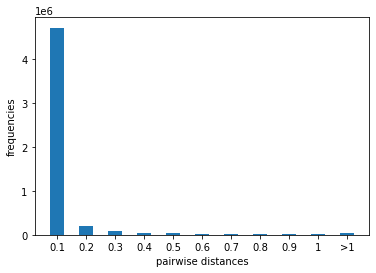

Min blength 0.0
Max blength 340.7852302089
proportion of zero bl: 3.436
proportion of bl <= 1: 99.202
proportion of bl <= 0.1 90.493


In [103]:
import numpy as np
from matplotlib import pyplot
import pandas as pd

df = pd.read_csv("../data/EvoNAPS_aa_branches.txt", sep="\t")
blengths=df['BL']
count = [0] * 11
for bl in blengths:
    if bl > 1:
        count[10] += 1
    else:
        count[int(bl * 10)] += 1
bar1 = pyplot.bar(np.arange(len(count)), count, width=0.5)

zero_count = 0
for bl in blengths:
    if bl == 0:
        zero_count += 1

#pyplot.legend( (bar1[0], bar2[0]), ('real', 'simulated'))
pyplot.ylabel('frequencies')
pyplot.xlabel('pairwise distances')
pyplot.xticks(np.arange(len(count)), [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,">1"])
pyplot.show()
print("Min blength", min(blengths))
print("Max blength", max(blengths))
print("proportion of zero bl:", "{:.3f}".format(zero_count/sum(count)*100))
print("proportion of bl <= 1:", "{:.3f}".format(sum(count[0:10])/sum(count)*100))
print("proportion of bl <= 0.1", "{:.3f}".format(count[0]/sum(count)*100))


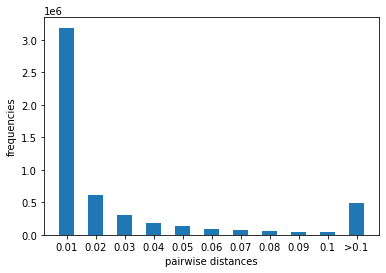

proportion of bl <= 0.1: 90.493
proportion of bl <= 0.05 84.490
proportion of bl <= 0.01 61.153


In [35]:
count = [0] * 11
for bl in blengths:
    if bl > 0.1:
        count[10] += 1
    else:
        count[int(bl * 100)] += 1
bar1 = pyplot.bar(np.arange(len(count)), count, width=0.5)

#pyplot.legend( (bar1[0], bar2[0]), ('real', 'simulated'))
pyplot.ylabel('frequencies')
pyplot.xlabel('pairwise distances')
pyplot.xticks(np.arange(len(count)), [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,">0.1"])
pyplot.show()

print("proportion of bl <= 0.1:", "{:.3f}".format(sum(count[0:10])/sum(count)*100))
print("proportion of bl <= 0.05", "{:.3f}".format(sum(count[0:5])/sum(count)*100))
print("proportion of bl <= 0.01", "{:.3f}".format(count[0]/sum(count)*100))



In [228]:
import numpy as np
from matplotlib import pyplot
import pandas as pd

df = pd.read_csv("../data/EvoNAPS_aa_trees.txt", sep="\t")
df1 = df.groupby(['BASE_MODEL']).size().reset_index(name='count').sort_values(ascending=False, by="count")
#print(df1)

count_F = 0
for index, row in df1.iterrows():
    if row['BASE_MODEL'].endswith("+F"):
        count_F += row['count']
        df1.loc[df1.BASE_MODEL == row['BASE_MODEL'], 'BASE_MODEL'] = row['BASE_MODEL'].replace("+F", "")

df2 = df1.groupby(['BASE_MODEL'])['count'].sum().reset_index(name='count').sort_values(ascending=False, by="count")
print(df2)
count = df2['count']

print("count_F:", count_F)

print("All: ", df1['count'].sum())



   BASE_MODEL  count
11     Q.bird  18392
9          LG   2159
13   Q.mammal   1919
15    Q.plant   1755
14     Q.pfam   1554
18        WAG    604
7         JTT    592
12   Q.insect    577
16    Q.yeast    563
17         VT    418
0    Blosum62    234
8    JTTDCMut    219
10        PMB    189
4         FLU    162
5        HIVb    118
26      mtZOA    116
23      mtMet    103
19      cpREV     93
27      rtREV     92
3       FLAVI     85
2     Dayhoff     66
21      mtInv     53
1       DCMut     43
6        HIVw     29
25      mtVer     19
22      mtMAM     12
24      mtREV     10
20      mtART      5
count_F: 3409
All:  30181


In [157]:
num_samples = sum(count)
print("Top 7")
print(df2['BASE_MODEL'][:7])
print("Top 7: ", sum(count[0:7]), " (~", "{:.3f}".format(sum(count[0:7]) / num_samples * 100), "%)")
print("Top 10")
print(df2['BASE_MODEL'][:10])
print("Top 10: ", sum(count[0:10]), " (~", "{:.3f}".format(sum(count[0:10]) / num_samples * 100), "%)")
print("Top 15")
print(df2['BASE_MODEL'][:15])
print("Top 15: ", sum(count[0:15]), " (~", "{:.3f}".format(sum(count[0:15]) / num_samples * 100), "%)")


Top 7
11      Q.bird
9           LG
13    Q.mammal
15     Q.plant
14      Q.pfam
18         WAG
7          JTT
Name: BASE_MODEL, dtype: object
Top 7:  26975  (~ 89.377 %)
Top 10
11      Q.bird
9           LG
13    Q.mammal
15     Q.plant
14      Q.pfam
18         WAG
7          JTT
12    Q.insect
16     Q.yeast
17          VT
Name: BASE_MODEL, dtype: object
Top 10:  28533  (~ 94.540 %)
Top 15
11      Q.bird
9           LG
13    Q.mammal
15     Q.plant
14      Q.pfam
18         WAG
7          JTT
12    Q.insect
16     Q.yeast
17          VT
0     Blosum62
8     JTTDCMut
10         PMB
4          FLU
5         HIVb
Name: BASE_MODEL, dtype: object
Top 15:  29455  (~ 97.595 %)


In [152]:
df3 = df.groupby(['RHAS_MODEL']).size().reset_index(name='count').sort_values(ascending=False, by="count")
for index, row in df3.iterrows():
    if "+I" in row['RHAS_MODEL']:
        df3.loc[df3.RHAS_MODEL == row['RHAS_MODEL'], 'RHAS_MODEL'] = "with +I"
    else:
        df3.loc[df3.RHAS_MODEL == row['RHAS_MODEL'], 'RHAS_MODEL'] = "without +I"

df4 = df3.groupby(['RHAS_MODEL'])['count'].sum().reset_index(name='count').sort_values(ascending=False, by="count")
print(df4)
count = df4['count']
print("With +I: ", df4.loc[df4.RHAS_MODEL == "with +I", 'count'].squeeze(), " (~", "{:.3f}".format(df4.loc[df4.RHAS_MODEL == "with +I", 'count'].squeeze() / num_samples * 100), "%)")
print("Without +I: ", df4.loc[df4.RHAS_MODEL == "without +I", 'count'].squeeze(), " (~", "{:.3f}".format(df4.loc[df4.RHAS_MODEL == "without +I", 'count'].squeeze() / num_samples * 100), "%)")

if sum(count) != num_samples:
    print("sum(count) != num_samples")
    print("sum(count): ", sum(count))
    print("num_samples: ", num_samples)


   RHAS_MODEL  count
1  without +I  21357
0     with +I   8824
With +I:  8824  (~ 29.237 %)
Without +I:  21357  (~ 70.763 %)


In [68]:
df3.loc[df3.RHAS_MODEL == "", 'RHAS_MODEL'].count()



0

In [72]:
df3 = df.groupby(['RHAS_MODEL']).size().reset_index(name='count').sort_values(ascending=False, by="count")
for index, row in df3.iterrows():
    if ("+G" in row['RHAS_MODEL']):
        df3.loc[df3.RHAS_MODEL == row['RHAS_MODEL'], 'RHAS_MODEL'] = "with +G"
    elif ("+R" in row['RHAS_MODEL']):
        df3.loc[df3.RHAS_MODEL == row['RHAS_MODEL'], 'RHAS_MODEL'] = "with +R"
    else:
        df3.loc[df3.RHAS_MODEL == row['RHAS_MODEL'], 'RHAS_MODEL'] = "without +G/+R"

df4 = df3.groupby(['RHAS_MODEL'])['count'].sum().reset_index(name='count').sort_values(ascending=False, by="count")
print(df4)
count = df4['count']
if sum(count) != num_samples:
    print("sum(count) != num_samples")
    print("sum(count): ", sum(count))
    print("num_samples: ", num_samples)

print("With +G: ", df4.loc[df4.RHAS_MODEL == "with +G", 'count'].squeeze(), " (~", "{:.3f}".format(df4.loc[df4.RHAS_MODEL == "with +G", 'count'].squeeze() / num_samples * 100), "%)")
print("With +R: ", df4.loc[df4.RHAS_MODEL == "with +R", 'count'].squeeze(), " (~", "{:.3f}".format(df4.loc[df4.RHAS_MODEL == "with +R", 'count'].squeeze() / num_samples * 100), "%)")
print("Without +G/+R: ", df4.loc[df4.RHAS_MODEL == "without +G/+R", 'count'].squeeze(), " (~", "{:.3f}".format(df4.loc[df4.RHAS_MODEL == "without +G/+R", 'count'].squeeze() / num_samples * 100), "%)")
print("With +G/+R: ", num_samples - df4.loc[df4.RHAS_MODEL == "without +G/+R", 'count'].squeeze(), " (~", "{:.3f}".format((num_samples - df4.loc[df4.RHAS_MODEL == "without +G/+R", 'count'].squeeze()) / num_samples * 100), "%)")


      RHAS_MODEL  count
0        with +G  16420
1        with +R  12400
2  without +G/+R   1361
With +G:  16420  (~ 54.405 %)
With +R:  12400  (~ 41.085 %)
Without +G/+R:  1361  (~ 4.509 %)
With +G/+R:  28820  (~ 95.491 %)


0        0.214100000
1        0.123000000
7        0.155800000
9        0.443600000
17       0.305500000
            ...     
30160    0.168400000
30168    0.227500000
30175    0.076300000
30176    0.149100000
30178    0.177400000
Name: PROP_INVAR, Length: 8823, dtype: object
0.001100000
0.951700000


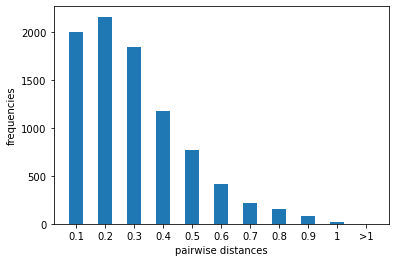

proportion of bl <= 1: 100.000
proportion of bl <= 0.5 94.662
proportion of bl <= 0.1 22.668


In [94]:
prop_invar = df.loc[df.PROP_INVAR != "None", 'PROP_INVAR']
print(prop_invar)
min_prop_invar = min(prop_invar)
max_prop_invar = max(prop_invar)
print (min_prop_invar)
print (max_prop_invar)

count = [0] * 11
for prop_invar_str in prop_invar:
    bl = float(prop_invar_str)
    if bl > 1:
        count[10] += 1
    else:
        count[int(bl * 10)] += 1
bar1 = pyplot.bar(np.arange(len(count)), count, width=0.5)

#pyplot.legend( (bar1[0], bar2[0]), ('real', 'simulated'))
pyplot.ylabel('frequencies')
pyplot.xlabel('pairwise distances')
pyplot.xticks(np.arange(len(count)), [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,">1"])
pyplot.show()

print("proportion of bl <= 1:", "{:.3f}".format(sum(count[0:10])/sum(count)*100))
print("proportion of bl <= 0.5", "{:.3f}".format(sum(count[0:5])/sum(count)*100))
print("proportion of bl <= 0.1", "{:.3f}".format(count[0]/sum(count)*100))




In [99]:
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

class Distribution(object):

    def __init__(self,dist_names_list = []):
        self.dist_names = ['alpha', 'beta', 'bradford', 'chi', 'chi2', 'dgamma',
                           'dweibull', 'erlang', 'exponnorm', 'exponweib',
                           'exponpow', 'gamma', 'genlogistic', 'genpareto',
                           'gennorm', 'genexpon', 'gengamma', 'halflogistic',
                           'halfnorm', 'halfgennorm', 'invgamma', 'invgauss',
                           'invweibull', 'laplace', 'loggamma', 'logistic',
                           'loglaplace', 'lognorm', 'maxwell', 'norm', 'pareto',
                           'powerlaw', 'powerlognorm', 'powernorm', 'uniform',
                           'weibull_max', 'weibull_min']
        self.dist_results = []
        self.params = {}

        self.DistributionName = ""
        self.PValue = 0
        self.Param = None

        self.isFitted = False


    def Fit(self, y):
            self.dist_results = []
            self.params = {}
            for dist_name in self.dist_names:
                dist = getattr(st, dist_name)
                param = dist.fit(y)

                self.params[dist_name] = param
                #Applying the Kolmogorov-Smirnov test
                D, p = st.kstest(y, dist_name, args=param);
                self.dist_results.append((dist_name,p))

            #select the best fitted distribution
            sel_dist,p = (max(self.dist_results,key=lambda item:item[1]))
            #store the name of the best fit and its p value
            self.DistributionName = sel_dist
            self.Param = self.params[sel_dist]
            self.PValue = p

            self.isFitted = True
            return self.DistributionName,self.PValue,self.Param

    def Random(self, n = 1):
        if self.isFitted:
            dist_name = self.DistributionName
            param = self.params[dist_name]
            #initiate the scipy distribution
            dist = getattr(st, dist_name)
            return dist.rvs(*param[:-2], loc=param[-2], scale=param[-1], size=n)
        else:
            raise ValueError('Must first run the Fit method.')

    def Plot(self,y,path):
        x = self.Random(n=len(y))
        hist, bins = np.histogram(y, bins=8)
        #logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
        logbins = 50
        plt.hist(x, alpha=0.5, label='fitted', range=[0,max(y)], bins=logbins)
        plt.hist(y, alpha=0.5, label='empirical', range=[0,max(y)], bins=logbins)
        #plt.xscale('log')
        plt.legend(loc='upper right')
        plt.savefig(path, dpi=600)

def fitDist(filename, field, min_val = 0, max_val = 1e10):
    '''
    Parameters
    ----------
    filename : path
        the csv file that contains the empirical values
    field: str
        the name of the field
    Returns
    ----------
    fitted_dist : the best fitted distribution
    '''
    df = pd.read_csv(filename, sep="\t")
    #emp_dist = [float(i) for i in df[field].values if i > 0.00001]
    emp_dist = [float(i) for i in df[field].values if ((i != "None") and (float(i) >= min_val) and (float(i) <= max_val))]
    dst = Distribution()
    dst.Fit(emp_dist)
    dst.Plot(emp_dist,os.path.splitext(filename)[0] + "_" + field+ '.png')
    return dst


/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2789: RuntimeWarning: invalid value encountered in double_scalars
  Lhat = muhat - Shat*mu
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:709: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:3180: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value 3.1500000000000004.
  warnings.warn(
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:3180: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value 3.1000000000000005.
  warnings.warn(
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:3

DistributionName:  genexpon
PValue:  0.4817043775496562
Param:  (0.5952992372206103, 2.4121269168114603, 0.6849512651146534, 0.0010999275638564044, 0.3251235787684815)


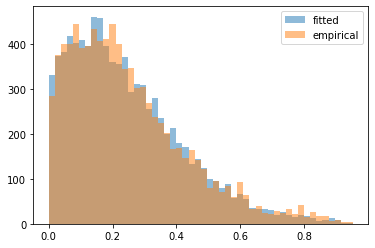

In [100]:
filename = "../data/EvoNAPS_aa_trees.txt"
field = "PROP_INVAR"
prop_invar_dist = fitDist(filename, field, min_val=0, max_val=1)

print("DistributionName: ", prop_invar_dist.DistributionName)
print("PValue: ", prop_invar_dist.PValue)
print("Param: ", prop_invar_dist.Param)


/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2789: RuntimeWarning: invalid value encountered in double_scalars
  Lhat = muhat - Shat*mu
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:709: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:3180: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value 1.05.
  warnings.warn(
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:3180: RuntimeWarning: The shape parameter of the erlang distribution has been given a non-integer value 1.0333333333333332.
  warnings.warn(
/Users/nhan/anaconda3/envs/Phyloformer/lib/python3.8/site-packages/scipy/stats/_continuous_distns.py:3180: RuntimeWa

DistributionName:  exponnorm
PValue:  0.23925313755464728
Param:  (4.017416816486817, 0.4328992743071488, 0.1872035813888447)


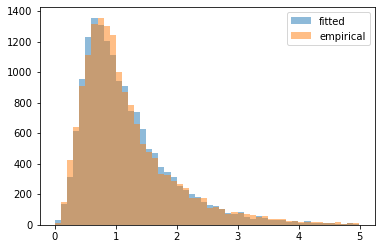

In [101]:
filename = "../data/EvoNAPS_aa_trees.txt"
field = "ALPHA"
alpha_dist = fitDist(filename, field, min_val=0, max_val=5)

print("DistributionName: ", alpha_dist.DistributionName)
print("PValue: ", alpha_dist.PValue)
print("Param: ", alpha_dist.Param)


3        1.473600000
4        0.902900000
5        1.533700000
6        0.546000000
8        0.385700000
            ...     
30175    2.920400000
30176    1.337800000
30178    1.923600000
30179    0.718200000
30180    0.940800000
Name: ALPHA, Length: 16420, dtype: object
0.020000000
9.348200000


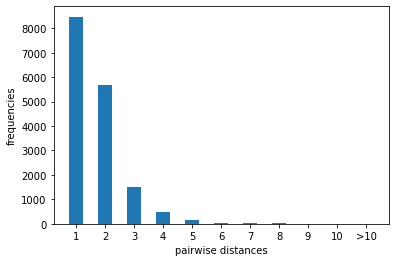

proportion of bl <= 10: 99.988
proportion of bl <= 5 99.354
proportion of bl <= 4 98.471
proportion of bl <= 3 95.499
proportion of bl <= 2 86.309
proportion of bl <= 1 51.614


In [98]:
alpha = df.loc[df.ALPHA != "None", 'ALPHA']
print(alpha)
min_alpha = min(alpha)
max_alpha = max(alpha)
print (min_alpha)
print (max_alpha)

count = [0] * 11
for alpha_str in alpha:
    bl = float(alpha_str)
    if bl > 10:
        count[10] += 1
    else:
        count[int(bl)] += 1
bar1 = pyplot.bar(np.arange(len(count)), count, width=0.5)

#pyplot.legend( (bar1[0], bar2[0]), ('real', 'simulated'))
pyplot.ylabel('frequencies')
pyplot.xlabel('pairwise distances')
pyplot.xticks(np.arange(len(count)), [1,2,3,4,5,6,7,8,9,10,">10"])
pyplot.show()

print("proportion of bl <= 10:", "{:.3f}".format(sum(count[0:10])/sum(count)*100))
print("proportion of bl <= 5", "{:.3f}".format(sum(count[0:5])/sum(count)*100))
print("proportion of bl <= 4", "{:.3f}".format(sum(count[0:4])/sum(count)*100))
print("proportion of bl <= 3", "{:.3f}".format(sum(count[0:3])/sum(count)*100))
print("proportion of bl <= 2", "{:.3f}".format(sum(count[0:2])/sum(count)*100))
print("proportion of bl <= 1", "{:.3f}".format(count[0]/sum(count)*100))


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


dist_bl 0.041702200470257 0.072032449344216 0.000011437481734 0.030233257263184 0.014675589081711 0.009233859476880 0.018626021137767 0.034556072704305 0.039676747423067 0.053881673400336 0.041919451440329 0.068521950039676 0.020445224973152 0.087811743639095 0.002738759319793 0.067046751017840 0.041730480236713 0.055868982844575 0.014038693859523 0.019810148908488 0.080074456867554 0.096826157571940 0.031342417815924 0.069232261566931 0.087638915229604 0.089460666350385 0.008504421136978 0.003905478323288 0.016983041956457 0.087814250342941 0.009834683383305 0.042110762500505 0.095788953015050 0.053316528497302 0.069187711395047 0.031551563100606 0.068650092768158 0.083462567189737 0.001828827734419 0.075014431494497 0.098886108890649 0.074816565437984 0.028044399206441 0.078927932845149 0.010322600657764 0.044789352617591 0.090859550309310 0.029361414837368 0.028777533858635 0.013002857211828 0.001936695787030 0.067883553293989 0.021162811600006 0.026554665937223 0.049157315928034 0.

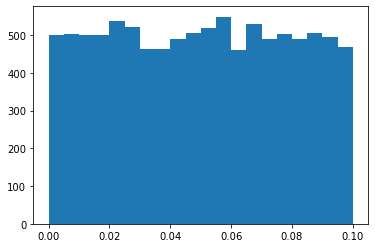

In [114]:
# generate random blengths from uniform distribution [0;0.1]
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
from scipy.stats import uniform

random_state = np.random.RandomState(seed=1)
rand_uniform = uniform.rvs(loc=0, scale=0.1, size=10000, random_state = random_state)
output = "dist_bl"
for rand_num in rand_uniform:
    output = output + " " + "{:.15f}".format(rand_num)
print(output)

ax.hist(rand_uniform, bins=20)
#ax.set_xlim([rand_uniform[0], rand_uniform[-1]])
ax.legend(loc='best', frameon=False)
plt.show()


#numbers:  10000
dist_prop_invar 0.072677943577119 0.100177672110701 0.184953598259155 0.002351851372847 0.155993979158875 0.238327897122613 0.162860763848973 0.293513831922015 0.058180131848929 0.126470262344041 0.112584867215623 0.497328494865390 0.405382619219842 0.374001766141229 0.079795698915937 0.446163634473791 0.027672037473313 0.365813130996357 0.744254848450960 0.426499440111563 0.116287552083647 0.203227847066239 0.293437230842223 0.143646580043291 0.177111225570911 0.189242478549433 0.105693878343401 0.131230170152683 0.216813059520560 0.196177258798605 0.281943471279342 0.405675417009318 0.177508107377827 0.152803113054085 0.783795680032133 0.179112903665406 0.169298651735505 0.265341486516180 0.153824333839999 0.329127040838200 0.510060975787959 0.416247530789685 0.041650138106976 0.288289960375699 0.102388970631630 0.323703698816539 0.003603091551349 0.246747096259283 0.140336551946767 0.343773522443651 0.248801645335386 0.573769323239057 0.157062114317948 0.08737865954

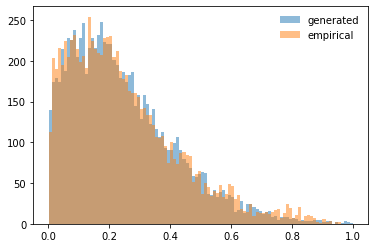

In [142]:
# generate prop_invar from genexpon distribution (0.5952992372206103, 2.4121269168114603, 0.6849512651146534, 0.0010999275638564044, 0.3251235787684815)
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
from scipy.stats import genexpon

num_numbers = 10000
max_val = 1
min_val = 1e-3
param=[0.5952992372206103, 2.4121269168114603, 0.6849512651146534, 0.0010999275638564044, 0.3251235787684815]
random_state = np.random.RandomState(seed=2)
rand_numbers = list(genexpon.rvs(*param[:-2], loc=param[-2], scale=param[-1], size=int(1.1 * num_numbers)))

# remove out of range values
for rand_num in rand_numbers:
    if (rand_num < min_val) or (rand_num > max_val):
        rand_numbers.remove(rand_num)
# make sure we have enough numbers left
if len(rand_numbers) < num_numbers:
    print("len(rand_numbers) < num_numbers")
else:
    rand_numbers = rand_numbers[:num_numbers]

print("#numbers: ", len(rand_numbers))


output = "dist_prop_invar"
for rand_num in rand_numbers:
    output = output + " " + "{:.15f}".format(rand_num)
print(output)

# read empirical
filename = "../data/EvoNAPS_aa_trees.txt"
field = "PROP_INVAR"
df = pd.read_csv(filename, sep="\t")
emp_dist = [float(i) for i in df[field].values if ((i != "None") and (float(i) >= min_val) and (float(i) <= max_val))]

min_samples = np.min([len(rand_numbers),len(emp_dist)])

ax.hist(rand_numbers[:min_samples], range=[min_val,max_val], bins=100, alpha=0.5, label='generated')
ax.hist(emp_dist[:min_samples], range=[min_val,max_val], bins=100, alpha=0.5, label='empirical')
#ax.set_xlim([rand_uniform[0], rand_uniform[-1]])
ax.legend(loc='best', frameon=False)
plt.show()

#numbers:  10000
dist_alpha 2.457314491177952 1.982341462526020 1.089602280940826 0.645044317435420 0.779937837693796 0.232156397755164 0.811419595250687 2.316046508258277 1.318158880877835 0.745074459007094 0.614472773238734 2.220069156632686 2.481834047603189 1.446409526360578 0.301280101760377 1.763661423094858 1.160379006406429 0.848876917724876 1.466527258747651 0.727295666816691 0.485247836504451 0.495690944315510 0.738106507597209 0.782347517369713 0.846070559121727 1.669652302031614 0.479787383849834 1.561717110632638 0.676355946009717 0.799873115584163 1.438373608246259 1.381432599612544 1.023604635551584 0.480415840891216 1.613003760194713 1.277699116414468 1.437859310402542 1.337868597484805 0.410843279077905 1.104545056084946 0.889948849599016 0.218184108749950 0.646419284523978 0.931372881457623 0.328590080717361 0.755607659511562 0.629071399105036 0.767160744368363 1.086725436940449 1.089790818870118 0.586143553695237 0.849031200945860 1.526060633238935 0.661387319277190 

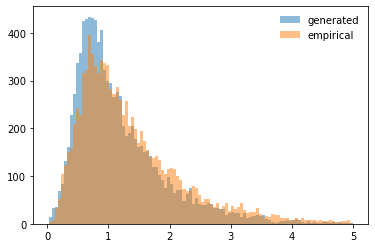

In [141]:
# generate alpha
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1)
from scipy.stats import exponnorm

num_numbers = 10000
max_val = 5
min_val = 0.02
param=[4.017416816486817, 0.4328992743071488, 0.1872035813888447]
random_state = np.random.RandomState(seed=3)
rand_numbers = list(exponnorm.rvs(*param[:-2], loc=param[-2], scale=param[-1], size=int(1.1 * num_numbers)))

# remove out of range values
for rand_num in rand_numbers:
    if (rand_num < min_val) or (rand_num > max_val):
        rand_numbers.remove(rand_num)
# make sure we have enough numbers left
if len(rand_numbers) < num_numbers:
    print("len(rand_numbers) < num_numbers")
else:
    rand_numbers = rand_numbers[:num_numbers]

print("#numbers: ", len(rand_numbers))


output = "dist_alpha"
for rand_num in rand_numbers:
    output = output + " " + "{:.15f}".format(rand_num)
print(output)

# read empirical
filename = "../data/EvoNAPS_aa_trees.txt"
field = "ALPHA"
df = pd.read_csv(filename, sep="\t")
emp_dist = [float(i) for i in df[field].values if ((i != "None") and (float(i) >= min_val) and (float(i) <= max_val))]

min_samples = np.min([len(rand_numbers),len(emp_dist)])

ax.hist(rand_numbers[:min_samples], range=[min_val,max_val], bins=100, alpha=0.5, label='generated')
ax.hist(emp_dist[:min_samples], range=[min_val,max_val], bins=100, alpha=0.5, label='empirical')
#ax.set_xlim([rand_uniform[0], rand_uniform[-1]])
ax.legend(loc='best', frameon=False)
plt.show()

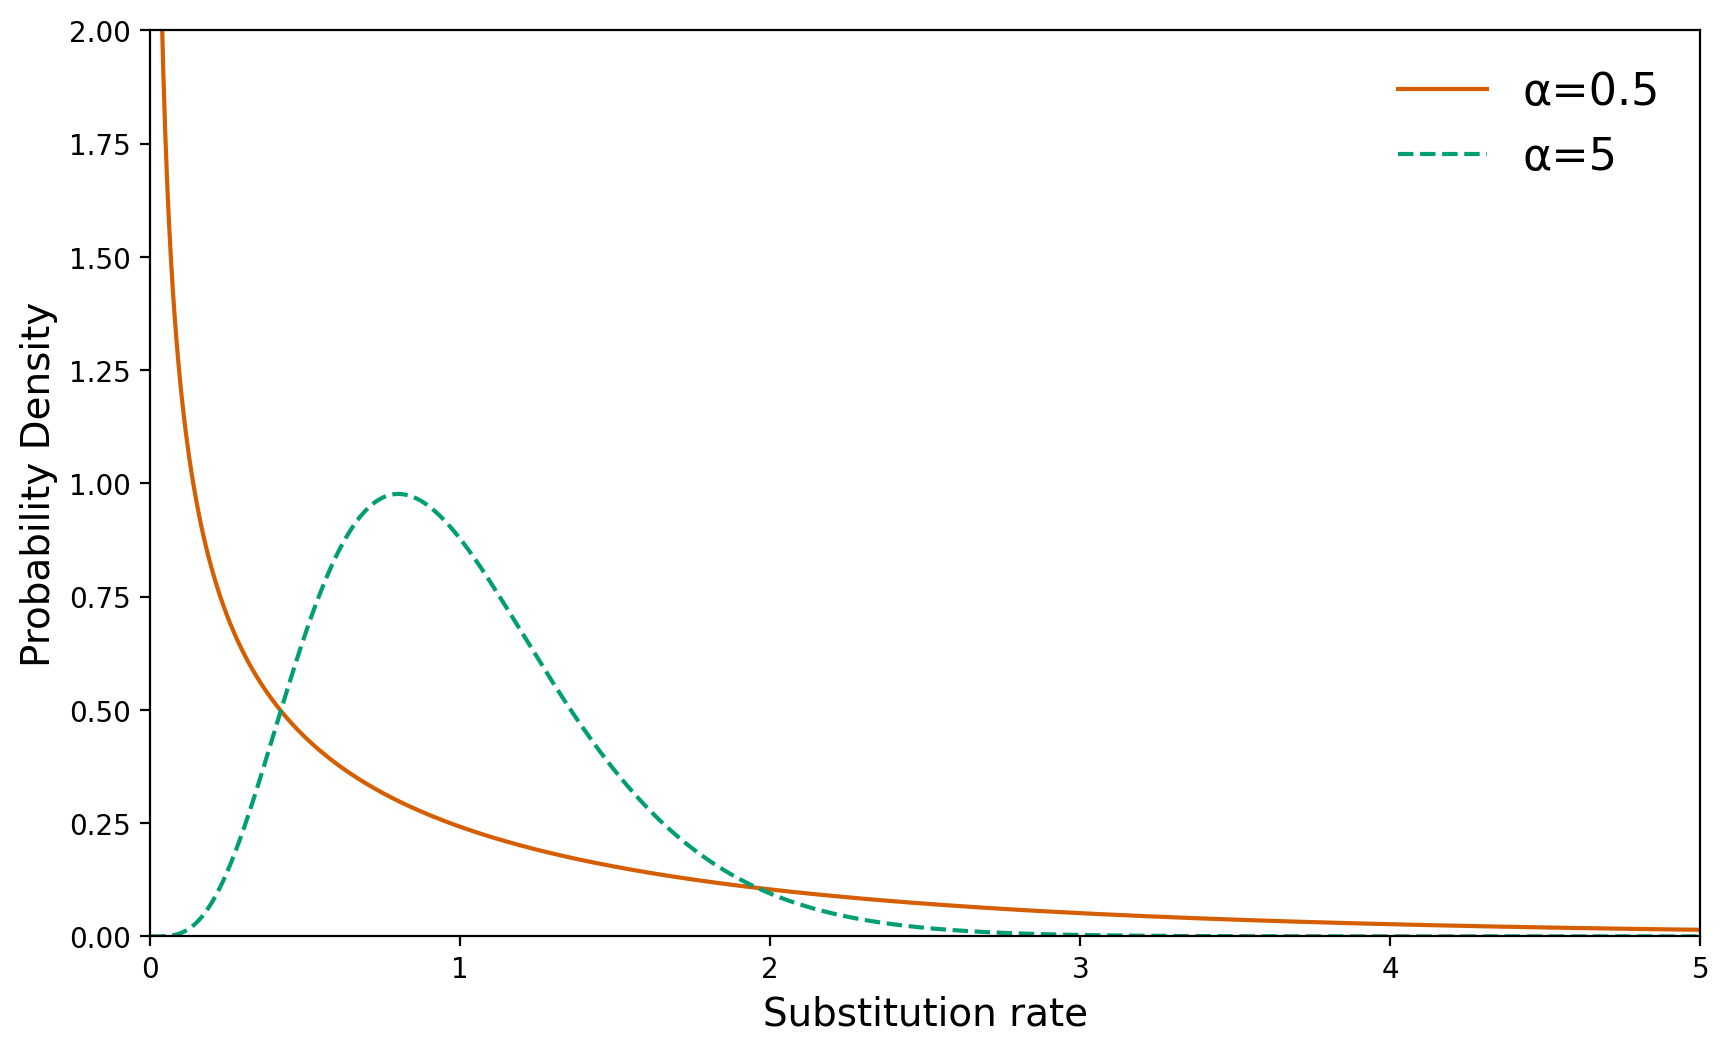

In [232]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Values for x axis
x = np.linspace(0, 6, 1000)

# Gamma distribution with shape parameter alpha=0.5
alpha_05 = gamma.pdf(x, a=0.5, scale=2)

# Gamma distribution with shape parameter alpha=5
alpha_3 = gamma.pdf(x, a=5, scale=0.2)

# Plotting the gamma distributions
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(x, alpha_05, label='α=0.5', color='#D55E00')
plt.plot(x, alpha_3, label='α=5', color='#009E73', linestyle='--')
plt.xlabel('Substitution rate', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
#plt.title('Gamma Distribution', fontsize=14)
plt.legend(fontsize=16, frameon=False)
plt.grid(False)
plt.ylim(0, 2)
plt.xlim(0, 5)
plt.show()


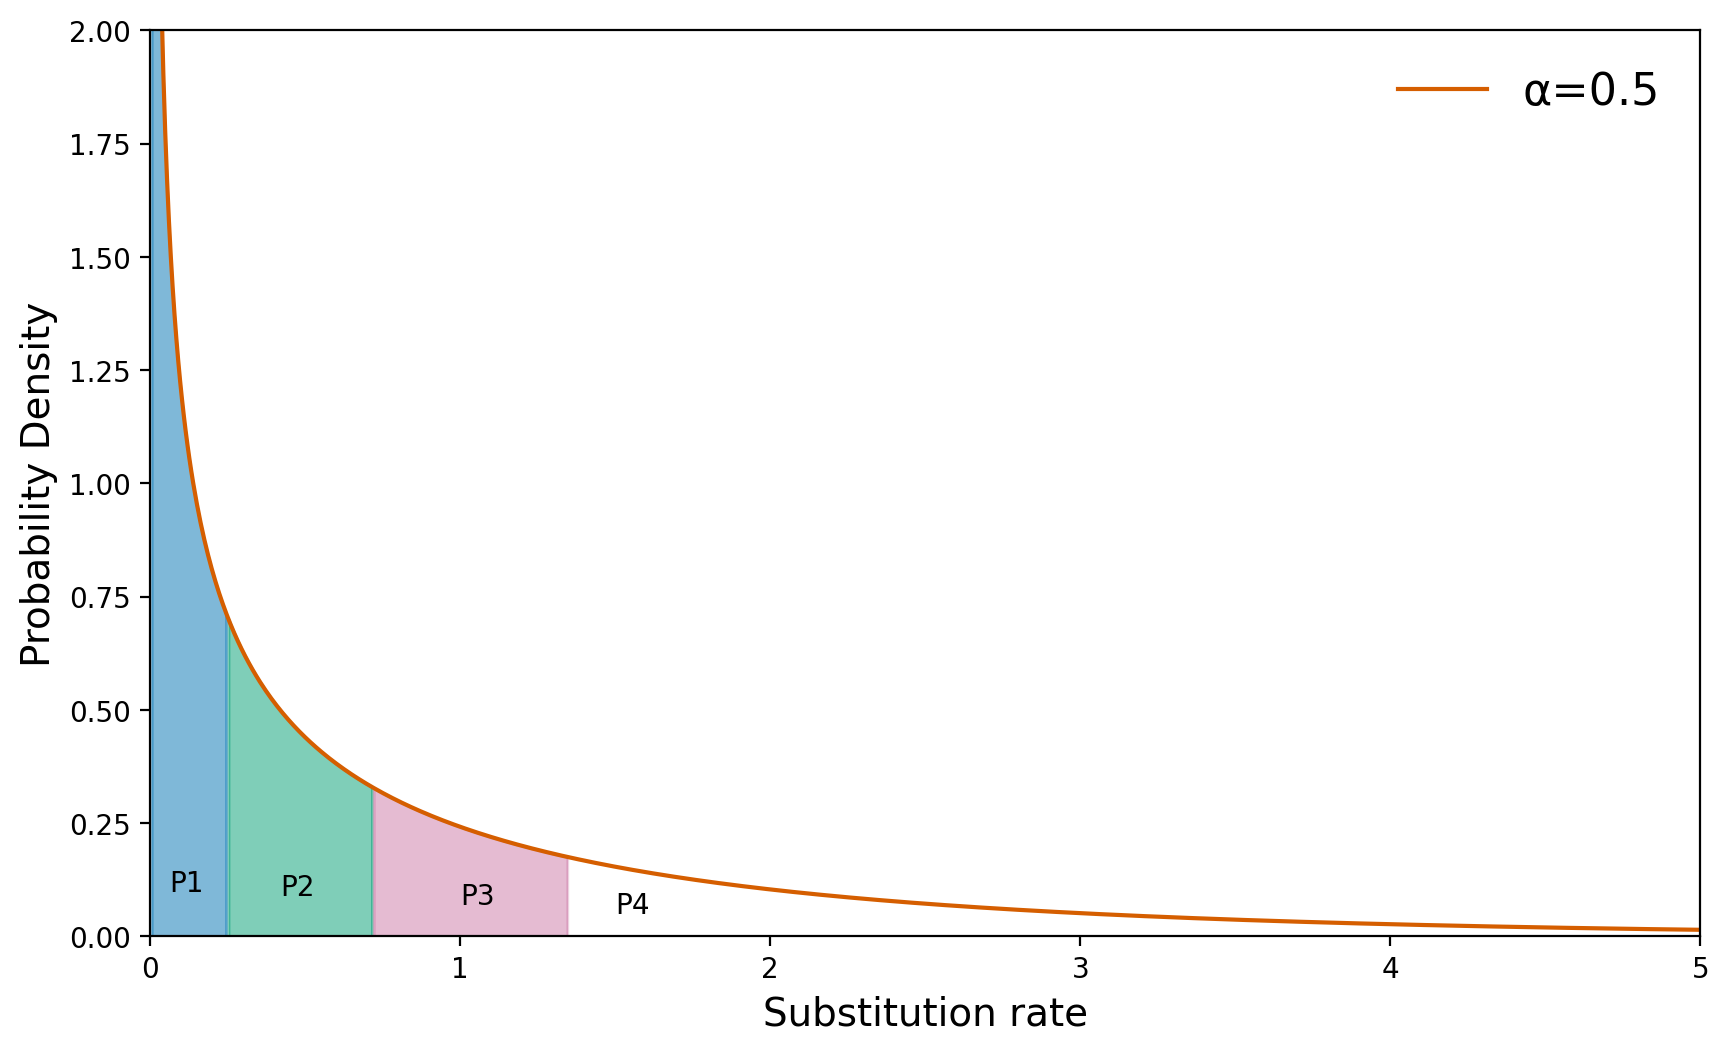

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Values for x axis
x = np.linspace(0, 6, 1000)
#x1 = np.linspace(0, 5, 1000)

# Gamma distribution with shape parameter alpha=0.5
alpha_05 = gamma.pdf(x, a=0.5, scale=2)
#alpha_05_1 = gamma.pdf(x1, a=0.5, scale=2)

# Gamma distribution with shape parameter alpha=5
alpha_3 = gamma.pdf(x, a=5, scale=0.2)

# Plotting the gamma distributions
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(x, alpha_05, label='α=0.5', color='#D55E00')
#plt.plot(x, alpha_3, label='α=5')
#plt.axvline(x=0.23, color='r', linestyle='--', label='x=0.23')
plt.fill_between(x, alpha_05, alpha=0.5, color='#0072B2', where=(x <= 0.25))
plt.text(0.06, 0.1, 'P1', fontsize=10, color='black')
plt.fill_between(x, alpha_05, alpha=0.5, color='#009E73', where=((x > 0.25) & (x <= 0.72)))
plt.text(0.42, 0.09, 'P2', fontsize=10, color='black')
plt.fill_between(x, alpha_05, alpha=0.5, color='#CC79A7', where=((x > 0.72) & (x <= 1.35)))
plt.text(1, 0.07, 'P3', fontsize=10, color='black')
plt.fill_between(x, alpha_05, alpha=0.5, color='#FFFFFF', where=((x > 1.35) & (x <= 5)))
plt.text(1.5, 0.05, 'P4', fontsize=10, color='black')

plt.xlabel('Substitution rate', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
#plt.title('Gamma Distribution', fontsize=14)
plt.legend(fontsize=16, frameon=False)
plt.grid(False)
plt.ylim(0, 2)
plt.xlim(0, 5)
plt.show()
